In [62]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier

In [9]:
def evaluate_model(y_test, y_pred, labels):
    print(classification_report(y_test, y_pred))
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy * 100:.2f}%')

    conf_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix Heatmap')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

In [3]:
data = pd.read_csv('../data/merged/data_model.csv')
data

,runtime,year,budget_adjusted,revenue_adjusted,quarter,director_movie_count,writer_movie_count,actors_avg_movie_count,writer_avg_revenue,writer_max_revenue,...,kw_new_york_city,kw_serial_killer,kw_revenge,kw_musical,kw_high_school,kw_small_town,kw_superhero,kw_alien,kw_biography,kw_fantasy_world
0,98,1995,8.449948e+06,8.993604e+06,4,15,13,8.2,2.384469e+08,5.964630e+08,...,0,0,0,0,0,0,0,0,0,0
1,109,1993,4.678756e+07,2.704085e+07,4,9,9,3.6,7.272651e+07,1.714053e+08,...,0,0,0,0,0,0,0,0,0,0
2,100,2003,1.644709e+08,1.645296e+09,2,9,7,12.4,1.081580e+09,1.645296e+09,...,0,0,0,0,0,0,0,0,0,0
3,142,1994,1.194795e+08,1.471527e+09,2,20,13,21.8,3.225962e+08,1.471527e+09,...,0,0,0,0,0,0,0,0,0,0
4,122,1999,2.898646e+07,6.885186e+08,3,9,1,9.0,6.885186e+08,6.885186e+08,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9181,137,2025,2.000000e+07,4.227859e+08,3,1,1,1.0,4.227859e+08,4.227859e+08,...,0,0,0,0,0,0,0,0,0,0
9182,224,2025,6.500000e+07,3.500000e+06,4,6,1,2.6,3.500000e+06,3.500000e+06,...,0,0,1,0,0,0,0,0,0,0
9183,88,2023,1.056583e+04,5.599891e+04,2,1,1,1.0,5.599891e+04,5.599891e+04,...,0,0,1,0,0,0,0,0,0,0
9184,127,2025,1.600000e+06,1.472934e+06,4,3,1,1.2,1.472934e+06,1.472934e+06,...,0,0,0,0,0,0,0,0,0,0


Podział na 3 klasy

In [4]:
data['revenue_category'], cut_bin = pd.qcut(data['revenue_adjusted'], q=3, labels=["LOW", "MEDIUM", "HIGH"], retbins=True)
print(f"Boundaries: {cut_bin}")
data['revenue_category'].value_counts()

Boundaries: [1.01788500e+04 1.18643720e+07 7.60370778e+07 4.54162754e+09]


revenue_category
LOW       3062
MEDIUM    3062
HIGH      3062
Name: count, dtype: int64

In [5]:
X = data.drop(columns=['revenue_adjusted', 'revenue_category'])
y = data['revenue_category']
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
y_train.value_counts(normalize=True)

revenue_category
HIGH      0.335738
MEDIUM    0.332608
LOW       0.331655
Name: proportion, dtype: float64

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

## Random Forest Classifier

              precision    recall  f1-score   support

        HIGH       0.85      0.96      0.90       595
         LOW       0.97      0.86      0.91       625
      MEDIUM       0.84      0.84      0.84       618

    accuracy                           0.88      1838
   macro avg       0.89      0.88      0.88      1838
weighted avg       0.89      0.88      0.88      1838

Accuracy: 88.36%


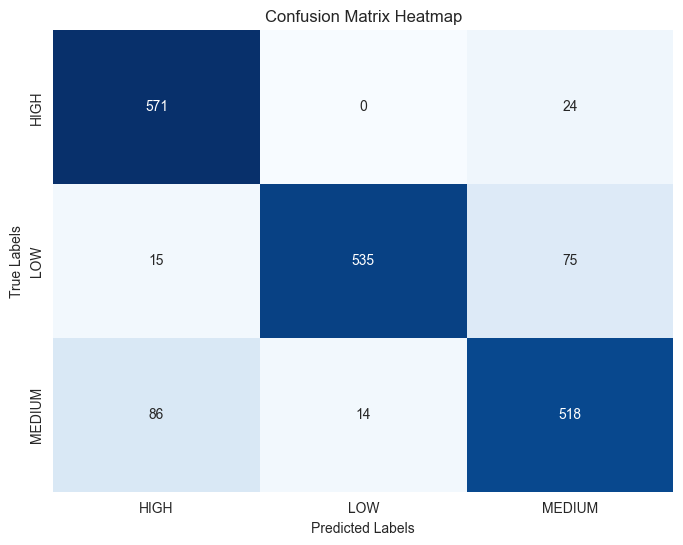

In [10]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
evaluate_model(y_test, y_pred, rf.classes_)

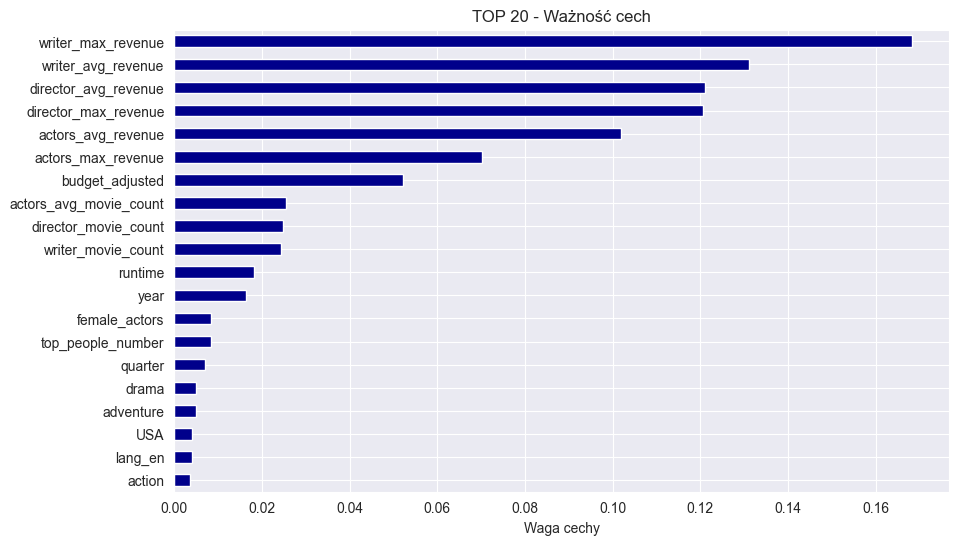

In [17]:
feature_importances = rf.feature_importances_

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()

In [9]:
param_grid = {
    'n_estimators': [200, 400, 800],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 0.8],
    'bootstrap': [True],
    'class_weight': [None, 'balanced']
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced', 'bootstrap': True}


              precision    recall  f1-score   support

        HIGH       0.86      0.97      0.91       595
         LOW       0.97      0.88      0.92       625
      MEDIUM       0.86      0.84      0.85       618

    accuracy                           0.89      1838
   macro avg       0.90      0.89      0.89      1838
weighted avg       0.90      0.89      0.89      1838

Accuracy: 89.28%


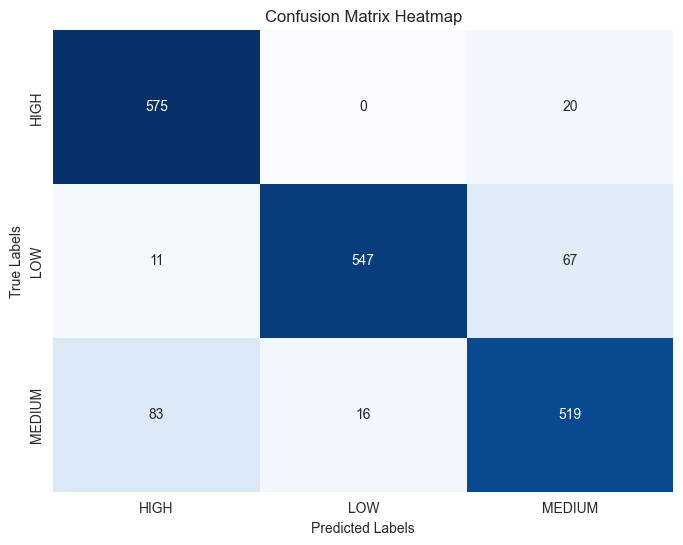

In [10]:
rf = RandomForestClassifier(**search.best_params_)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate_model(y_test, y_pred, rf.classes_)

              precision    recall  f1-score   support

        HIGH       0.86      0.97      0.91       595
         LOW       0.97      0.88      0.92       625
      MEDIUM       0.86      0.84      0.85       618

    accuracy                           0.89      1838
   macro avg       0.90      0.89      0.89      1838
weighted avg       0.90      0.89      0.89      1838

Accuracy: 89.28%


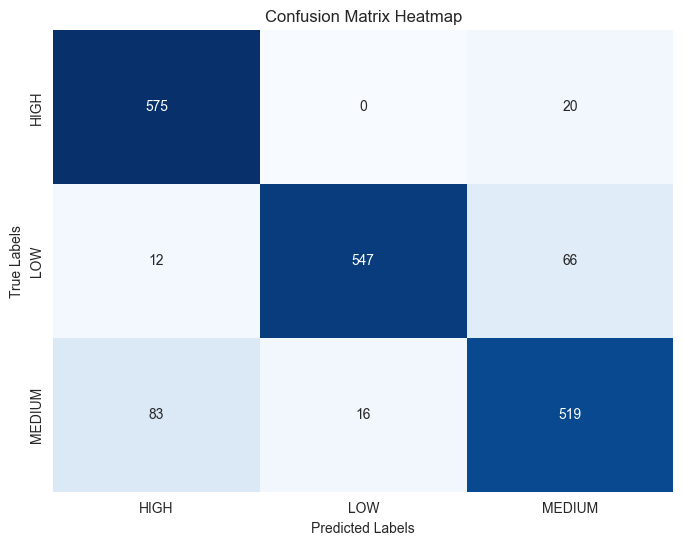

In [23]:
X_train_sample = X_train_raw[importances.index]
X_test_sample = X_test_raw[importances.index]

scaler = StandardScaler()
X_train_sample = scaler.fit_transform(X_train_sample)
X_test_sample = scaler.transform(X_test_sample)

rf = RandomForestClassifier(**search.best_params_)
rf.fit(X_train_sample, y_train)
y_pred = rf.predict(X_test_sample)
evaluate_model(y_test, y_pred, rf.classes_)

## XGB Classifier

In [12]:
y_map = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
classes = ["LOW", "MEDIUM", "HIGH"]
y_train_encoded = y_train.map(y_map)
y_test_encoded = y_test.map(y_map)

              precision    recall  f1-score   support

           0       0.96      0.88      0.92       625
           1       0.84      0.86      0.85       618
           2       0.88      0.94      0.91       595

    accuracy                           0.89      1838
   macro avg       0.89      0.89      0.89      1838
weighted avg       0.89      0.89      0.89      1838

Accuracy: 89.12%


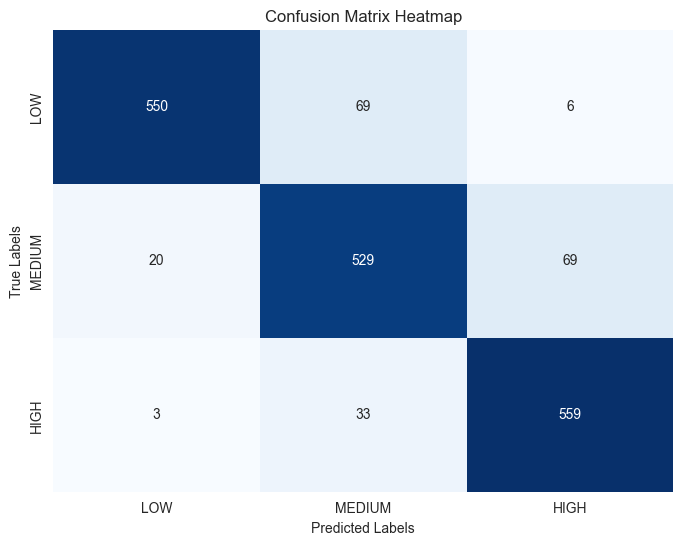

In [13]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train_encoded)

y_pred = xgb.predict(X_test)
evaluate_model(y_test_encoded, y_pred, labels=classes)

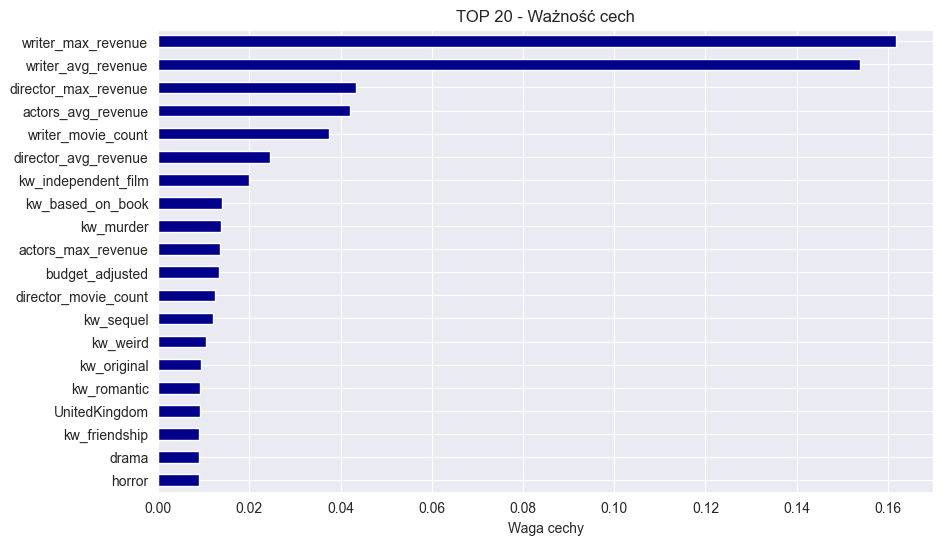

In [34]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()

In [19]:
params = {
    "learning_rate": [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5],
    "max_depth": [3, 4, 5, 6, 8, 10, 12, 15],
    "min_child_weight": [1, 2, 3, 4, 5, 6, 7, 8],
    "gamma": [0.0, 0.1, 0.2 , 0.3, 0.4, 0.5, 0.7],
    "colsample_bytree": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2, 5],
    "n_estimators": [200, 500, 1000]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=50,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
    verbose=3
)

search.fit(X_train, y_train_encoded)
print("Best parameters:", search.best_params_)
search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.4, 'gamma': 0.7, 'colsample_bytree': 0.8}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

              precision    recall  f1-score   support

           0       0.97      0.88      0.93       625
           1       0.85      0.85      0.85       618
           2       0.87      0.95      0.91       595

    accuracy                           0.89      1838
   macro avg       0.90      0.90      0.90      1838
weighted avg       0.90      0.89      0.90      1838

Accuracy: 89.50%


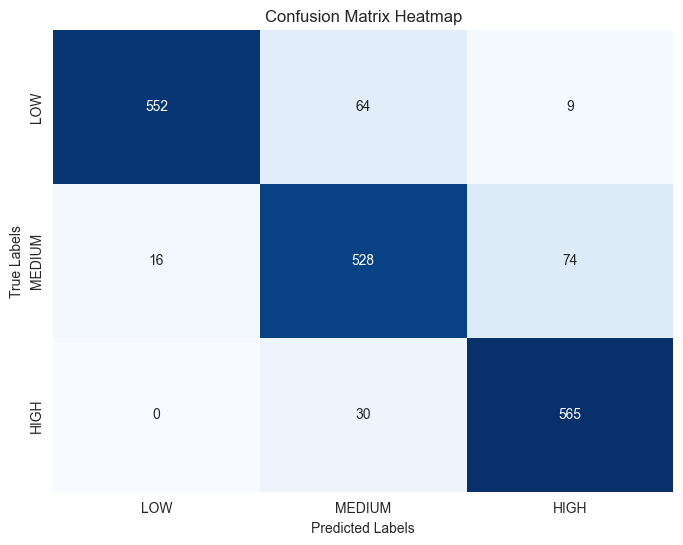

In [31]:
xgb = XGBClassifier(**search.best_params_)
xgb.fit(X_train, y_train_encoded)

y_pred = xgb.predict(X_test)
evaluate_model(y_test_encoded, y_pred, classes)

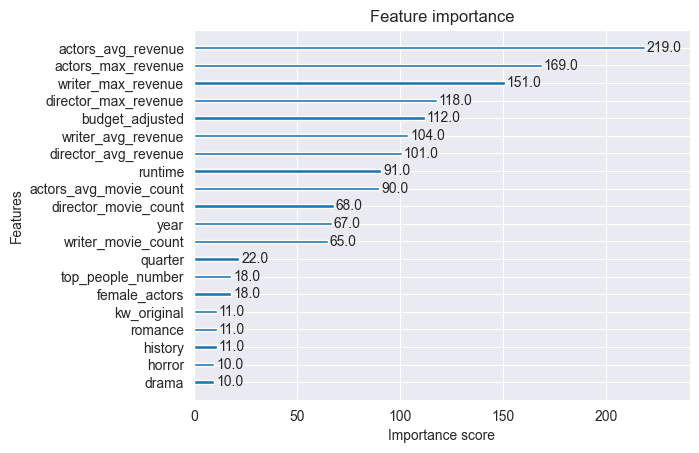

In [29]:
from xgboost import plot_importance

xgb.get_booster().feature_names = list(X_train_raw.columns)
plot_importance(xgb, max_num_features=20)
plt.show()

## MLP

In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [58]:
y_train_encoded = y_train_encoded.astype("int32")
y_test_encoded = y_test_encoded.astype("int32")

In [72]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(3, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [73]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_encoded,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5163 - loss: 1.0305 - val_accuracy: 0.6367 - val_loss: 0.7831
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5912 - loss: 0.8490 - val_accuracy: 0.6544 - val_loss: 0.7335
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6256 - loss: 0.7741 - val_accuracy: 0.6701 - val_loss: 0.7039
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6575 - loss: 0.7317 - val_accuracy: 0.6762 - val_loss: 0.6873
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6677 - loss: 0.7109 - val_accuracy: 0.6844 - val_loss: 0.6675
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6808 - loss: 0.6827 - val_accuracy: 0.6925 - val_loss: 0.6505
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6928 - loss: 0.6564 - val_accuracy: 0.6905 - val_loss: 0.6456
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6977 - loss: 0.6430 - val_accu

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       625
           1       0.64      0.71      0.67       618
           2       0.84      0.83      0.83       595

    accuracy                           0.77      1838
   macro avg       0.77      0.77      0.77      1838
weighted avg       0.77      0.77      0.77      1838

Accuracy: 76.61%


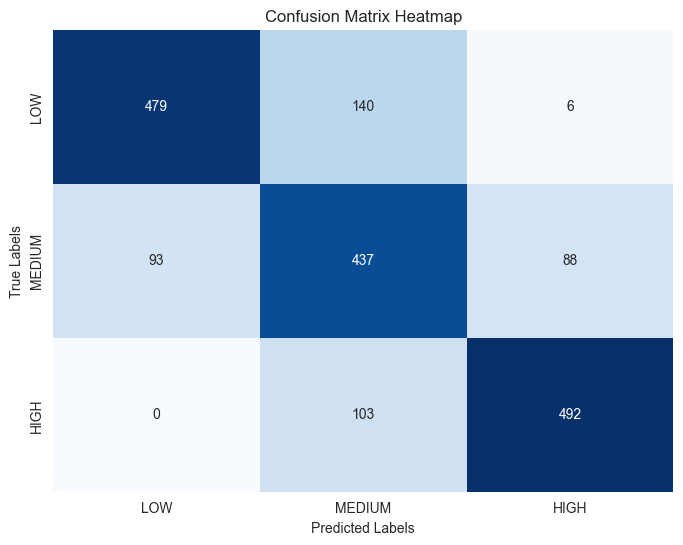

In [75]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
evaluate_model(y_test_encoded, y_pred, classes)

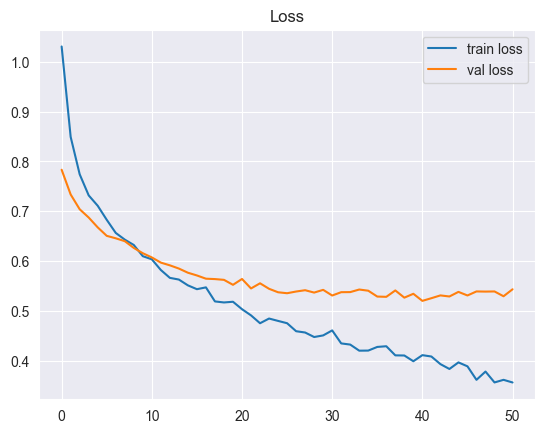

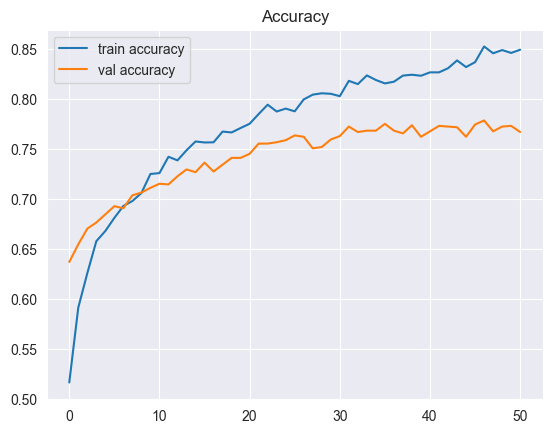

In [76]:
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

## CATBoost Classifier

In [77]:
from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cb.fit(X_train, y_train_encoded)

CatBoostClassifier(depth=6, iterations=100, learning_rate=0.1, verbose=0)

              precision    recall  f1-score   support

           0       0.98      0.86      0.92       625
           1       0.83      0.85      0.84       618
           2       0.86      0.96      0.90       595

    accuracy                           0.89      1838
   macro avg       0.89      0.89      0.89      1838
weighted avg       0.89      0.89      0.89      1838

Accuracy: 88.63%


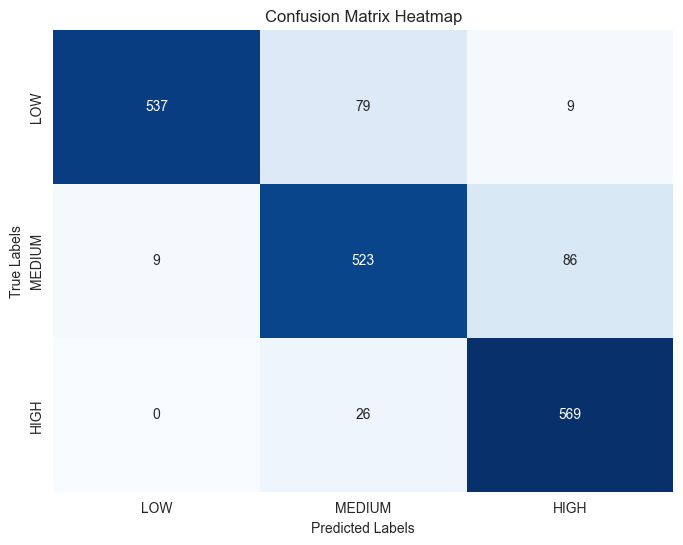

In [78]:
y_pred = cb.predict(X_test)
evaluate_model(y_test_encoded, y_pred, labels=classes)

In [79]:
cb = CatBoostClassifier(
    loss_function='MultiClass',
    verbose=0
)

param_dist = {
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations": [200, 500, 1000],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128],
    "bagging_temperature": [0, 0.5, 1, 2],
    "random_strength": [0, 1, 2, 5]
}

result = cb.randomized_search(
    param_dist,
    X=X_train,
    y=y_train_encoded,
    cv=5,
    n_iter=30,
    stratified=True,
    verbose=False
)

print(result["params"])


bestTest = 0.258909699
bestIteration = 497


bestTest = 0.2465933742
bestIteration = 997


bestTest = 0.2880622029
bestIteration = 499


bestTest = 0.2560704384
bestIteration = 499


bestTest = 0.3059543277
bestIteration = 199


bestTest = 0.3844721996
bestIteration = 199


bestTest = 0.2432311341
bestIteration = 994


bestTest = 0.2507624042
bestIteration = 498


bestTest = 0.273568351
bestIteration = 499


bestTest = 0.2713017324
bestIteration = 999


bestTest = 0.2425510181
bestIteration = 195


bestTest = 0.3061115107
bestIteration = 499


bestTest = 0.2976138511
bestIteration = 199


bestTest = 0.2368666278
bestIteration = 499


bestTest = 0.2537756236
bestIteration = 999


bestTest = 0.2903286512
bestIteration = 499


bestTest = 0.2915599397
bestIteration = 499


bestTest = 0.2576541103
bestIteration = 199


bestTest = 0.2459584109
bestIteration = 996


bestTest = 0.2499091603
bestIteration = 498


bestTest = 0.2770679533
bestIteration = 199


bestTest = 0.2314836116
bestIterati

              precision    recall  f1-score   support

           0       0.97      0.88      0.92       625
           1       0.84      0.85      0.85       618
           2       0.87      0.95      0.91       595

    accuracy                           0.89      1838
   macro avg       0.90      0.89      0.89      1838
weighted avg       0.90      0.89      0.89      1838

Accuracy: 89.34%


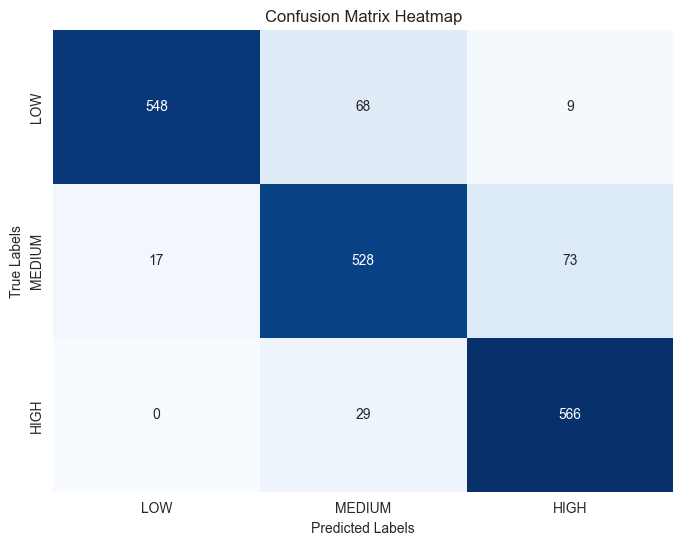

In [80]:
y_pred = cb.predict(X_test)
evaluate_model(y_test_encoded, y_pred, labels=classes)

In [94]:
importances = cb.get_feature_importance()
features = X_train_raw.columns

df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

df

,feature,importance
8,writer_max_revenue,13.175530
11,actors_avg_revenue,10.050393
7,writer_avg_revenue,9.293993
10,director_max_revenue,7.580395
9,director_avg_revenue,6.763169
...,...,...
77,kw_new_york_city,0.016807
79,kw_revenge,0.010285
25,film-noir,0.005129
21,documentary,0.000000


In [99]:
top_n = 20

selected_features = df.head(top_n)["feature"]
X_train_sel = X_train_raw[selected_features]
X_test_sel = X_test_raw[selected_features]

scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel = scaler.transform(X_test_sel)

selected_features

8         writer_max_revenue
11        actors_avg_revenue
7         writer_avg_revenue
10      director_max_revenue
9       director_avg_revenue
2            budget_adjusted
5         writer_movie_count
12        actors_max_revenue
1                       year
6     actors_avg_movie_count
0                    runtime
4       director_movie_count
3                    quarter
13             female_actors
14         top_people_number
33                  thriller
22                     drama
47               kw_original
20                     crime
31                   romance
Name: feature, dtype: object

0:	learn: 1.0035480	total: 27.4ms	remaining: 24.6s
1:	learn: 0.9192821	total: 47.7ms	remaining: 21.4s
2:	learn: 0.8430492	total: 64.5ms	remaining: 19.3s
3:	learn: 0.7778257	total: 82ms	remaining: 18.4s
4:	learn: 0.7289148	total: 102ms	remaining: 18.2s
5:	learn: 0.6880638	total: 121ms	remaining: 18s
6:	learn: 0.6513891	total: 139ms	remaining: 17.8s
7:	learn: 0.6165072	total: 156ms	remaining: 17.4s
8:	learn: 0.5871408	total: 174ms	remaining: 17.3s
9:	learn: 0.5606085	total: 193ms	remaining: 17.2s
10:	learn: 0.5386352	total: 213ms	remaining: 17.2s
11:	learn: 0.5128276	total: 232ms	remaining: 17.2s
12:	learn: 0.4961888	total: 256ms	remaining: 17.5s
13:	learn: 0.4842163	total: 286ms	remaining: 18.1s
14:	learn: 0.4738061	total: 321ms	remaining: 18.9s
15:	learn: 0.4607560	total: 366ms	remaining: 20.2s
16:	learn: 0.4485380	total: 395ms	remaining: 20.5s
17:	learn: 0.4366728	total: 424ms	remaining: 20.8s
18:	learn: 0.4282415	total: 474ms	remaining: 22s
19:	learn: 0.4186686	total: 523ms	remaining

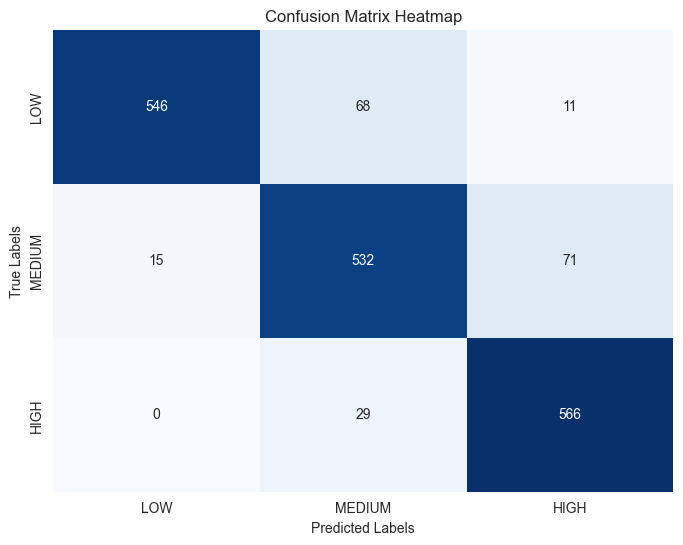

In [100]:
cb.fit(X_train_sel, y_train_encoded)
y_pred = cb.predict(X_test_sel)
evaluate_model(y_test_encoded, y_pred, labels=classes)

In [102]:
best_params = {'border_count': 128, 'bagging_temperature': 1, 'random_strength': 5, 'depth': 8, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 800}
cb = CatBoostClassifier(**best_params)
cb.fit(X_train, y_train_encoded)

0:	learn: 0.9958916	total: 30.5ms	remaining: 24.4s
1:	learn: 0.9058555	total: 57.3ms	remaining: 22.9s
2:	learn: 0.8409994	total: 82.5ms	remaining: 21.9s
3:	learn: 0.7898447	total: 106ms	remaining: 21.2s
4:	learn: 0.7495193	total: 131ms	remaining: 20.8s
5:	learn: 0.7096386	total: 158ms	remaining: 20.9s
6:	learn: 0.6781642	total: 182ms	remaining: 20.6s
7:	learn: 0.6413846	total: 206ms	remaining: 20.4s
8:	learn: 0.6100566	total: 230ms	remaining: 20.3s
9:	learn: 0.5847795	total: 257ms	remaining: 20.3s
10:	learn: 0.5624136	total: 284ms	remaining: 20.4s
11:	learn: 0.5455656	total: 313ms	remaining: 20.5s
12:	learn: 0.5230134	total: 348ms	remaining: 21.1s
13:	learn: 0.5047849	total: 382ms	remaining: 21.4s
14:	learn: 0.4900498	total: 419ms	remaining: 21.9s
15:	learn: 0.4772347	total: 457ms	remaining: 22.4s
16:	learn: 0.4662283	total: 491ms	remaining: 22.6s
17:	learn: 0.4579598	total: 531ms	remaining: 23.1s
18:	learn: 0.4459193	total: 569ms	remaining: 23.4s
19:	learn: 0.4338505	total: 603ms	rema

CatBoostClassifier(bagging_temperature=1, border_count=128, depth=8, iterations=800, l2_leaf_reg=1, learning_rate=0.1, random_strength=5)

              precision    recall  f1-score   support

           0       0.97      0.88      0.92       625
           1       0.85      0.85      0.85       618
           2       0.88      0.95      0.91       595

    accuracy                           0.89      1838
   macro avg       0.90      0.90      0.89      1838
weighted avg       0.90      0.89      0.89      1838

Accuracy: 89.45%


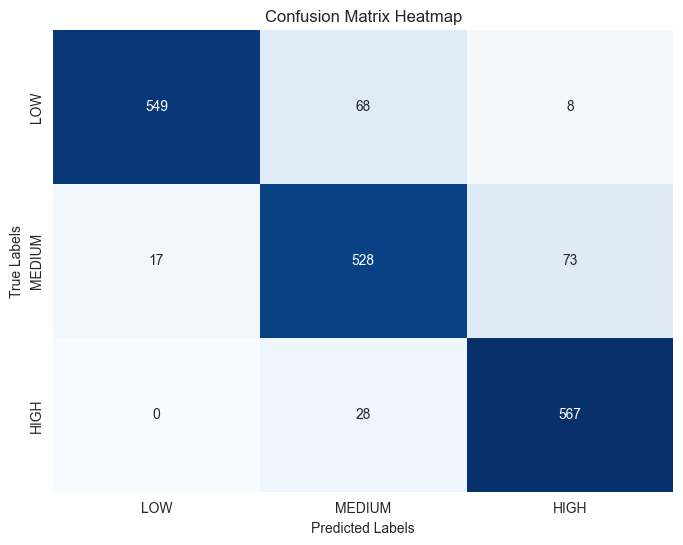

In [103]:
y_pred = cb.predict(X_test)
evaluate_model(y_test_encoded, y_pred, labels=classes)

Ensemble

              precision    recall  f1-score   support

           0       0.97      0.88      0.93       625
           1       0.85      0.86      0.85       618
           2       0.88      0.95      0.91       595

    accuracy                           0.90      1838
   macro avg       0.90      0.90      0.90      1838
weighted avg       0.90      0.90      0.90      1838

Accuracy: 89.66%


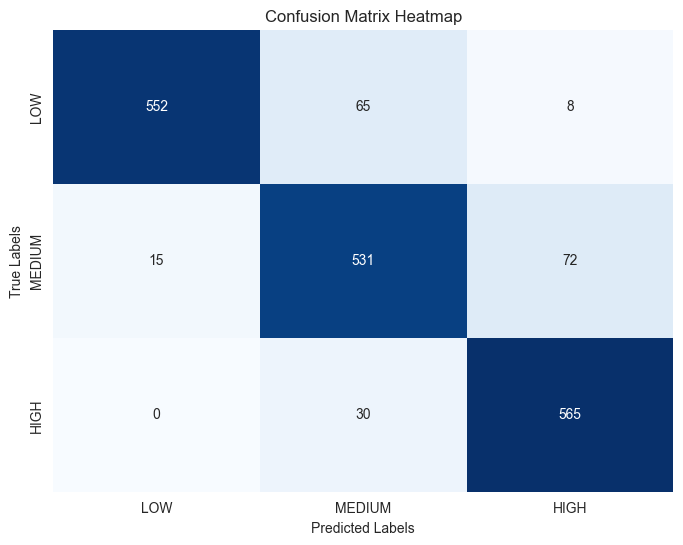

In [104]:
final_pred = (
    0.5 * xgb.predict_proba(X_test) +
    0.5 * cb.predict_proba(X_test)
)

y_pred = np.argmax(final_pred, axis=1)
evaluate_model(y_test_encoded, y_pred, labels=classes)

Najlepszy XGBoost W artykule przy 3 klasach mają max 87% a my 89%, także <3